# Land Type Classification using Sentinel-2 Satellite Images
### **ResNet Edition**
***

#### Imports:

In [11]:
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf

from tensorflow.python.platform.build_info import build_info
from tensorflow.config.experimental import list_physical_devices, VirtualDeviceConfiguration, set_virtual_device_configuration #type:ignore

from tensorflow.keras.regularizers import l2 #type:ignore
from tensorflow.keras.optimizers import Adam, RMSprop, SGD #type:ignore
from tensorflow.keras.models import Sequential #type:ignore
from tensorflow.keras.applications import ResNet50  #type:ignore
from tensorflow.keras.applications.resnet50 import preprocess_input #type:ignore
from tensorflow.keras.losses import CategoricalCrossentropy # type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint #type:ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator #type:ignore
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout #type:ignore
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D, LeakyReLU, AveragePooling2D #type:ignore
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.models import load_model #type:ignore

from pathlib import Path
import os
import shutil
import random

#### Parameters and Settings:

In [12]:
params = { 
    "dense_units": 512,
    "dropout": 0.43061630752233415,
    "optimizer": "rmsprop",
    "lr": 0.0026520878741265364,
    "unfreeze_from": "conv5_block3_out",
    "img_size": (96,96),
    "random_state": 36
}

#### Set seeds:

In [13]:
random.seed(params["random_state"])
np.random.seed(params["random_state"])
tf.random.set_seed(params["random_state"])

***
### GPU Setup `tensorflow`
 1. Check if GPU register
 2. limiting VRAM (CUDA will allocate whole VRAM by Default)

In [14]:
print(tf.__version__)

GPU_RUN: bool = False

if list_physical_devices("GPU") != []:
    GPU_RUN = True
            
def limit_gpu_vram(vram = None):
    if vram == None:
        print("[!] Maximum GPU memory allowed")
        return
    
    gpus = list_physical_devices("GPU")
    try:
        set_virtual_device_configuration( gpus[0], [VirtualDeviceConfiguration(memory_limit= vram * 1024)] )
        print(f"[/] Limited GPU memory to {vram} GB.")
    except RuntimeError as e:
        print(e)

if GPU_RUN:
    print(tf.config.list_physical_devices("GPU"))

    print("-"*19)

    print("CUDA:", build_info["cuda_version"]) #type:ignore
    print("cuDNN:", build_info["cudnn_version"]) #type:ignore

    print("-"*19)
    
    limit_gpu_vram()


2.17.1


***
### Had to re-define `CategoricalFocalLoss` as it was missing in this old version of tensorflow
 - should have the same functionanlity

In [15]:
from tensorflow.keras.losses import Loss #type:ignore
from tensorflow.keras import backend as K #type:ignore

categorical_focal = None
if GPU_RUN:
    print("[!] Using custom GPU focal loss")
    class CategoricalFocalLoss(Loss):
        def __init__(self, gamma=2.0, alpha=0.25, from_logits=False, reduction=tf.keras.losses.Reduction.AUTO, name="categorical_focal_loss"): #type:ignore
            super().__init__(reduction=reduction, name=name)
            self.gamma = float(gamma)
            self.alpha = float(alpha)
            self.from_logits = from_logits

        def call(self, y_true, y_pred):
            if self.from_logits:
                y_pred = tf.nn.softmax(y_pred, axis=-1)
            eps = K.epsilon()
            y_pred = K.clip(y_pred, eps, 1.0 - eps)

            cross_entropy = -y_true * K.log(y_pred)

            p_t = K.sum(y_true * y_pred, axis=-1, keepdims=True)
            focal_factor = K.pow(1.0 - p_t, self.gamma)
            
            loss = self.alpha * focal_factor * cross_entropy
            loss = K.sum(loss, axis=-1)
            return K.mean(loss)

        def get_config(self):
            return {"gamma": self.gamma, "alpha": self.alpha, "from_logits": self.from_logits}
        
    categorical_focal = CategoricalFocalLoss()
else:
    print("[!] Using built-in CPU focal loss")
    from tensorflow.keras.losses import CategoricalFocalCrossentropy #type:ignore
    categorical_focal = CategoricalFocalCrossentropy()
    
print(categorical_focal)

[!] Using built-in CPU focal loss
<LossFunctionWrapper(<function categorical_focal_crossentropy at 0x000002550C0AF1A0>, kwargs={'alpha': 0.25, 'gamma': 2.0, 'from_logits': False, 'label_smoothing': 0.0, 'axis': -1})>


#### Split data into folders

In [16]:
project_root = Path(os.getcwd()).parent

dataset_root = project_root / "Dataset"
original_folder = dataset_root / "EuroSAT_RGB"
base_folder = dataset_root / "EuroSAT_RGB_split"

checkpoints_dir = project_root  / "Ready_Models" 

print("Project Root:       ",project_root)
print("Dataset Root:       ",dataset_root)
print("Original Root:      ",original_folder)
print("Base Folder:        ",base_folder)
print("Checkpoints Folder: ",checkpoints_dir)

Project Root:        c:\Users\S1NdBAD\Desktop\DEPI Final Project
Dataset Root:        c:\Users\S1NdBAD\Desktop\DEPI Final Project\Dataset
Original Root:       c:\Users\S1NdBAD\Desktop\DEPI Final Project\Dataset\EuroSAT_RGB
Base Folder:         c:\Users\S1NdBAD\Desktop\DEPI Final Project\Dataset\EuroSAT_RGB_split
Checkpoints Folder:  c:\Users\S1NdBAD\Desktop\DEPI Final Project\Ready_Models


In [17]:
def split_data():
    train_ratio = 0.7
    val_ratio = 0.15
    random_state = 42
    random.seed(random_state)

    for split in ["train", "validate", "test"]:
        os.makedirs(os.path.join(base_folder, split), exist_ok=True)
    
    for class_name in os.listdir(original_folder):
        class_path = os.path.join(original_folder, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path) if f.lower().endswith((".jpg", ".png", ".tif"))]
        random.shuffle(images)

        n_total = len(images)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        splits = {
            "train": images[:n_train],
            "validate": images[n_train:n_train + n_val],
            "test": images[n_train + n_val:]
        }

        for split_name, split_images in splits.items():
            split_dir = os.path.join(base_folder, split_name, class_name)
            os.makedirs(split_dir, exist_ok=True)

            for img_name in split_images:
                src = os.path.join(class_path, img_name)
                dst = os.path.join(split_dir, img_name)
                shutil.copy(src, dst)

        print(f"{class_name}: {n_total} images split into train/val/test")

In [18]:
#split_data()

#### split_data() Output:
 - AnnualCrop: 3000 images split into train/val/test
 - Forest: 3000 images split into train/val/test
 - HerbaceousVegetation: 3000 images split into train/val/test
 - Highway: 2500 images split into train/val/test
 - Industrial: 2500 images split into train/val/test
 - Pasture: 2000 images split into train/val/test
 - PermanentCrop: 2500 images split into train/val/test
 - Residential: 3000 images split into train/val/test 
 - River: 2500 images split into train/val/test 
 - SeaLake: 3000 images split into train/val/test


In [19]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    base_folder / "train",
    target_size=params["img_size"],
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    base_folder / "validate",
    target_size=params["img_size"],
    batch_size=32,
    class_mode="categorical",
    shuffle=False 
)

test_generator = val_test_datagen.flow_from_directory(
    base_folder / "test",
    target_size=params["img_size"],
    batch_size=32,
    class_mode="categorical",
    shuffle=False 
)

Found 18900 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.


***
### **Model (**`CNN`**) Training**

In [20]:
tf.config.run_functions_eagerly(True)

base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(*params["img_size"], 3)
)

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(params["dense_units"], activation="relu", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(params["dropout"]),
    Dense(train_generator.num_classes, activation="softmax")
])

if params["optimizer"] == "adam":
    opt = Adam(learning_rate=params["lr"])
elif params["optimizer"] == "rmsprop":
    opt = RMSprop(learning_rate=params["lr"])
else:
    opt = SGD(learning_rate=params["lr"], momentum=0.9)

modelcheckpoint = ModelCheckpoint(str(checkpoints_dir / f"model_resnet50.h5"), monitor="val_loss", save_best_only=True, verbose=0)
if not GPU_RUN:
    modelcheckpoint = ModelCheckpoint(str(checkpoints_dir / f"model_resnet50.keras"), monitor="val_loss", save_best_only=True, verbose=0)


model.compile(
    optimizer = Adam(learning_rate=params["lr"]), 
    loss = categorical_focal,
    metrics = ["accuracy"]
)

callbacks = [
    modelcheckpoint,
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.33, patience=2, min_lr=1e-6)
]

base_model.trainable = False

history_phase1 = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs = 20,  # Initial training epochs
    callbacks = callbacks,
    verbose = 1
)

### Phase II
# unfreeze all except last N layers
unfreeze_from_layer_name = params["unfreeze_from"]
unfreeze_from_index = next(
    i for i, l in enumerate(base_model.layers) if l.name == unfreeze_from_layer_name
)

# 1) Freeze ALL layers first
for layer in base_model.layers:
    layer.trainable = False

# 2) Unfreeze ONLY layers from selected layer onward
for layer in base_model.layers[unfreeze_from_index:]:
    layer.trainable = True

model.compile(
    optimizer = opt,  # lower lr
    loss = categorical_focal,
    metrics = ["accuracy"]
)

history_phase2 = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs = 25,  # Additional fine-tuning epochs
    callbacks = callbacks,
    verbose = 1
)

history = {
    "accuracy": history_phase1.history["accuracy"] + history_phase2.history["accuracy"],
    "val_accuracy": history_phase1.history["val_accuracy"] + history_phase2.history["val_accuracy"],
    "loss": history_phase1.history["loss"] + history_phase2.history["loss"],
    "val_loss": history_phase1.history["val_loss"] + history_phase2.history["val_loss"]
}

Epoch 1/20


c:\Users\S1NdBAD\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
c:\Users\S1NdBAD\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


591/591 ━━━━━━━━━━━━━━━━━━━━ 785s 1s/step - accuracy: 0.4949 - loss: 0.2700 - val_accuracy: 0.1180 - val_loss: 3.2182 - learning_rate: 0.0027
Epoch 2/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 791s 1s/step - accuracy: 0.5157 - loss: 0.2464 - val_accuracy: 0.2059 - val_loss: 2.3915 - learning_rate: 0.0027
Epoch 3/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 774s 1s/step - accuracy: 0.5153 - loss: 0.2401 - val_accuracy: 0.1353 - val_loss: 3.0278 - learning_rate: 0.0027
Epoch 4/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 752s 1s/step - accuracy: 0.5217 - loss: 0.2377 - val_accuracy: 0.1111 - val_loss: 3.4867 - learning_rate: 0.0027
Epoch 5/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 751s 1s/step - accuracy: 0.5472 - loss: 0.2203 - val_accuracy: 0.2605 - val_loss: 1.9533 - learning_rate: 8.7519e-04
Epoch 6/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 747s 1s/step - accuracy: 0.5562 - loss: 0.2150 - val_accuracy: 0.1635 - val_loss: 1.1297 - learning_rate: 8.7519e-04
Epoch 7/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 754s 1s/step - accuracy: 0.5598 - loss: 0.211

***
#### Load Model:

In [21]:
#model = tf.keras.models.load_model("model.h5")

#### Print used VRAM:

In [22]:
if GPU_RUN:
    gpus = tf.config.list_physical_devices("GPU")
    details = tf.config.experimental.get_memory_info(gpus[0].name[17:])
    
    print(f"[/] GPU: {gpus[0].name}")
    print(f"  Used VRAM: {details["current"] / 1024**2:.2f} MB")
    print(f"  Peak VRAM: {details["peak"] / 1024**2:.2f} MB")
else:
    print("[!] No GPU used")

[!] No GPU used


#### **Model Test**

In [23]:
def evaluate_model(model, test_ds, class_names):
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f"\nTest Results:\nAccuracy: {test_acc:.4f} | Loss: {test_loss:.4f}")

    preds = model.predict(test_ds, verbose=1)
    y_pred = np.argmax(preds, axis=1)

    if hasattr(test_ds, "labels"):
        y_true = test_ds.labels
    else:
        y_true = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds], axis=0)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    return test_acc, test_loss, y_pred


Test Results:
Accuracy: 0.0758 | Loss: 3.1451
127/127 ━━━━━━━━━━━━━━━━━━━━ 74s 580ms/step


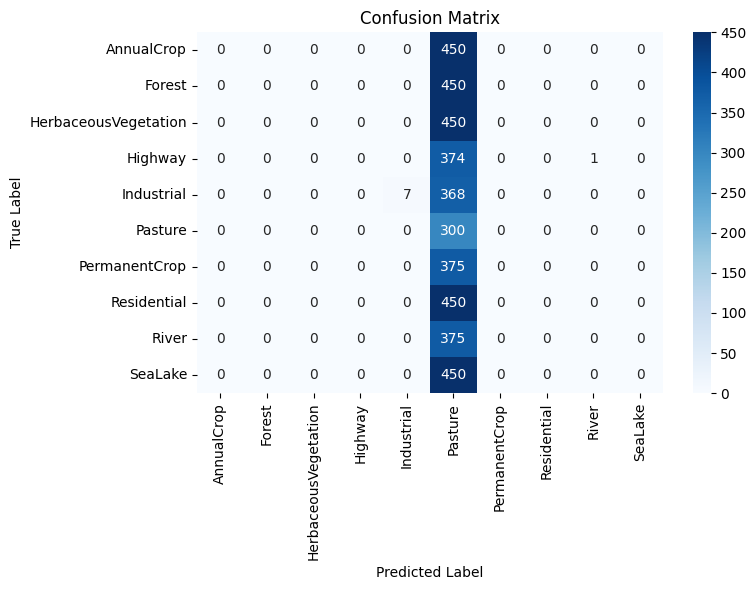


Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop     0.0000    0.0000    0.0000       450
              Forest     0.0000    0.0000    0.0000       450
HerbaceousVegetation     0.0000    0.0000    0.0000       450
             Highway     0.0000    0.0000    0.0000       375
          Industrial     1.0000    0.0187    0.0366       375
             Pasture     0.0742    1.0000    0.1382       300
       PermanentCrop     0.0000    0.0000    0.0000       375
         Residential     0.0000    0.0000    0.0000       450
               River     0.0000    0.0000    0.0000       375
             SeaLake     0.0000    0.0000    0.0000       450

            accuracy                         0.0758      4050
           macro avg     0.1074    0.1019    0.0175      4050
        weighted avg     0.0981    0.0758    0.0136      4050



c:\Users\S1NdBAD\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\S1NdBAD\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\S1NdBAD\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

In [24]:
test_acc, test_loss, y_pred = evaluate_model(model, test_generator, list(test_generator.class_indices.keys()))

***
#### **Plot Training Process**

In [25]:
def plot_training_curves(history, test_acc=0):
    acc = history["accuracy"]
    val_acc = history["val_accuracy"]
    epochs_range = range(len(acc))
    phase2epoch = 20
    plt.figure(figsize=(14, 5))

    plt.plot(epochs_range, acc, label="Train Acc")
    plt.plot(epochs_range, val_acc, label="Val Acc")
    plt.axhline(y=test_acc, linestyle="--", color="green", label=f"Test Acc: {test_acc:.2f}")
    plt.axvspan(
        phase2epoch, len(epochs_range) - 1,    
        color="skyblue",                   
        alpha=0.20,                    
        label="Fine-Tuning Phase"      
    )    
    plt.title("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

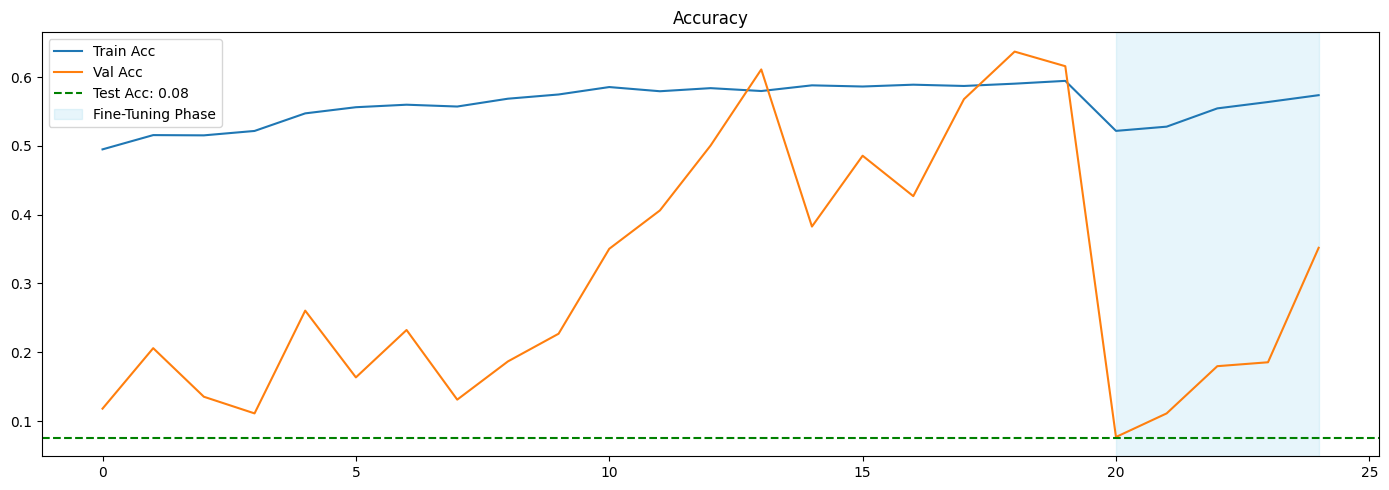

In [26]:
plot_training_curves(history, test_acc=test_acc)

***
#### Pick **Random** Image as test

c:\Users\S1NdBAD\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step


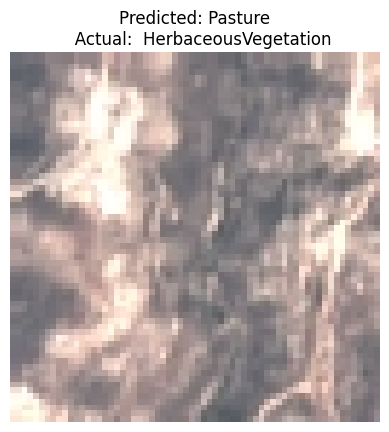

In [27]:
def random_image(model):
    basefolder = dataset_root / "EuroSAT_RGB_split"
    class_names = list(test_generator.class_indices.keys())
    
    all_image_paths = []
    
    for split_dir in os.listdir(basefolder):
        split_path = os.path.join(basefolder, split_dir)
        if os.path.isdir(split_path):
            for class_dir in os.listdir(split_path):
                class_path = os.path.join(split_path, class_dir)
                if os.path.isdir(class_path):
                    for fname in os.listdir(class_path):
                        if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                            full_path = os.path.join(class_path, fname)
                            all_image_paths.append(full_path)
    
    
    random_image_path = random.choice(all_image_paths)
    image_type = random_image_path.split("\\")[-1].split("_")[0]
    
    img = cv2.imread(random_image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #type: ignore
    img_resized = cv2.resize(img, params["img_size"])
    img_array = np.expand_dims(img_resized, axis=0) / 255.0
    
    pred = model.predict(img_array)
    pred_class = class_names[np.argmax(pred)]
    
    plt.imshow(img)
    plt.title(f"Predicted: {pred_class}\n   Actual:  {image_type}")
    plt.axis("off")
    plt.show()
    
random_image(model)

***
#### Save:
 1. Keras
 2. Pickle

In [28]:
# model.save(checkpoints_dir / "model_resnet50.keras")
loaded_model = load_model(checkpoints_dir / "model_resnet50.keras", compile=True)


Test Results:
Accuracy: 0.6210 | Loss: 0.1842
127/127 ━━━━━━━━━━━━━━━━━━━━ 70s 554ms/step


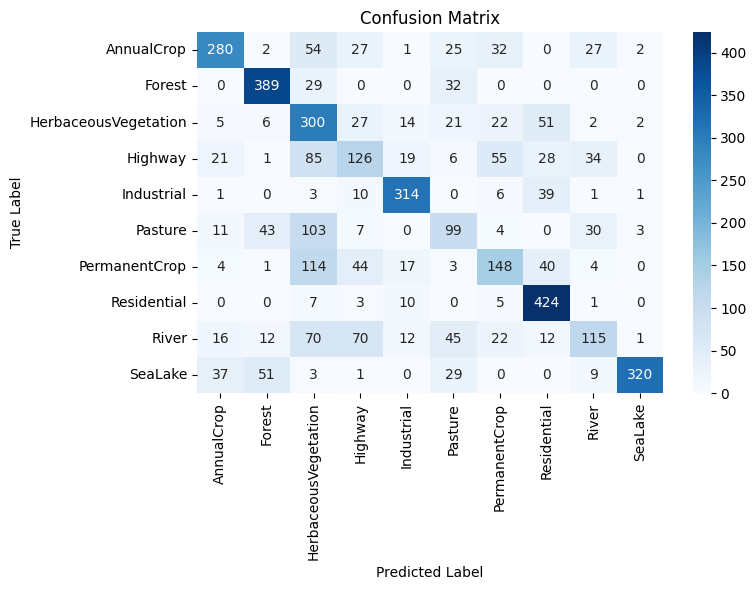


Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop     0.7467    0.6222    0.6788       450
              Forest     0.7703    0.8644    0.8147       450
HerbaceousVegetation     0.3906    0.6667    0.4926       450
             Highway     0.4000    0.3360    0.3652       375
          Industrial     0.8114    0.8373    0.8241       375
             Pasture     0.3808    0.3300    0.3536       300
       PermanentCrop     0.5034    0.3947    0.4425       375
         Residential     0.7138    0.9422    0.8123       450
               River     0.5157    0.3067    0.3846       375
             SeaLake     0.9726    0.7111    0.8216       450

            accuracy                         0.6210      4050
           macro avg     0.6205    0.6011    0.5990      4050
        weighted avg     0.6341    0.6210    0.6151      4050



In [29]:
_, _, _ = evaluate_model(loaded_model, test_generator, list(test_generator.class_indices.keys()))

c:\Users\S1NdBAD\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step


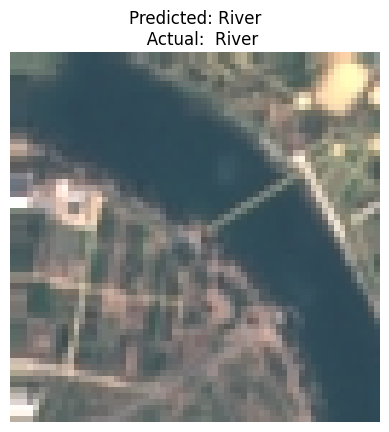

In [30]:
random_image(loaded_model)

[/] Model saved as pickle
[/] Model loaded from pickle

Test Results:
Accuracy: 0.0758 | Loss: 3.1451
127/127 ━━━━━━━━━━━━━━━━━━━━ 75s 593ms/step


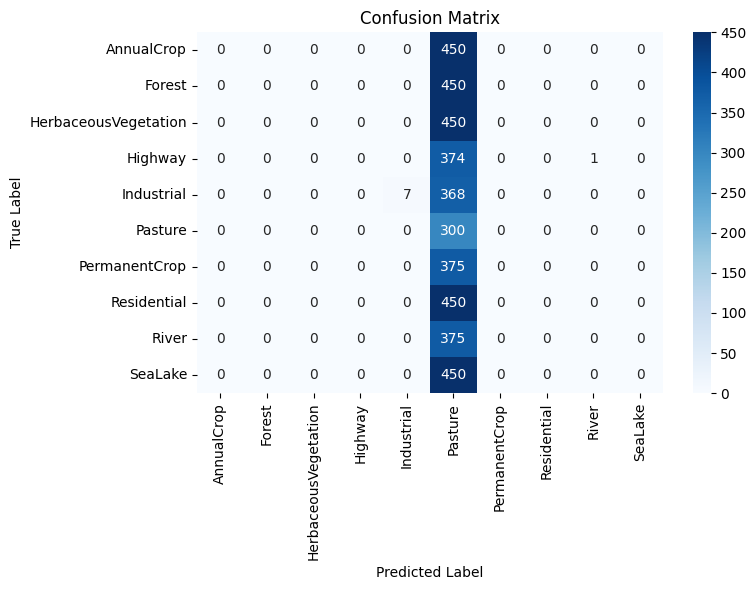


Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop     0.0000    0.0000    0.0000       450
              Forest     0.0000    0.0000    0.0000       450
HerbaceousVegetation     0.0000    0.0000    0.0000       450
             Highway     0.0000    0.0000    0.0000       375
          Industrial     1.0000    0.0187    0.0366       375
             Pasture     0.0742    1.0000    0.1382       300
       PermanentCrop     0.0000    0.0000    0.0000       375
         Residential     0.0000    0.0000    0.0000       450
               River     0.0000    0.0000    0.0000       375
             SeaLake     0.0000    0.0000    0.0000       450

            accuracy                         0.0758      4050
           macro avg     0.1074    0.1019    0.0175      4050
        weighted avg     0.0981    0.0758    0.0136      4050



c:\Users\S1NdBAD\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\S1NdBAD\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\S1NdBAD\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

In [31]:
import pickle

try:
    with open(checkpoints_dir / "model_resnet50.pkl", "wb") as f:
        pickle.dump(model, f)
    print("[/] Model saved as pickle")
    
except Exception as e:
    print(f"[x] Pickle save failed: {e}")


try:
    with open(checkpoints_dir / "model_resnet50.pkl", "rb") as f:
        loaded_model = pickle.load(f)
    print("[/] Model loaded from pickle")
    
    test_acc, test_loss, y_pred = evaluate_model(loaded_model, test_generator, list(test_generator.class_indices.keys()))
    
except Exception as e:
    print(f"[x] Pickle load failed: {e}")